In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
# import glob
# import dill as pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import torch
import nibabel as nb

from tqdm.auto import tqdm

DATA7_PATH = "/System/Volumes/Data/data/data7"
projects_path = f"{DATA7_PATH}/network_control/projects"
sys.path.insert(1, projects_path)
import CAP_tools

NC_path = f"{DATA7_PATH}/network_control/projects/network_control"
sys.path.insert(1, NC_path)
import plot
import surface_mapping as sfm
import load

import voxel_analysis as va

# Load Data:
### Parameters / Load ptseries and DTI-As

In [2]:
N_PARCELS = 400

data_types = ["rfMRI_REST1_7T_PA", "tfMRI_MOVIE_7T_DAY_1"]
data_exts = ["_hp2000_clean_nilearn", "_hp2000_clean_nilearn_ISCH"]

In [3]:
DTI_parcellation, fMRI_parcellation, _, subject_list = load.load_constants(N_PARCELS)
tf_arrays, template_cifti = load.load_ptseries(subject_list, data_types,
                                               data_exts, fMRI_parcellation)

rfMRI_all, tfMRI_all = tf_arrays["rfMRI_all"], tf_arrays["tfMRI_all"]
ROI_labels, network_labels = load.load_labels(template_cifti)

Loading ptseries:   0%|          | 0/172 [00:00<?, ?it/s]

### Load in CAP States

In [4]:
CAP_analysis_label = "tfMRI_MOVIE_7T_DAY_1"
isc = 0
K = 12
state_norm = 0

In [5]:
CAP_pkl_path = load.get_CAP_pkl_path(CAP_analysis_label, K, isc=isc)
CAP_states, CAP_labels, n_CAPs = load.load_CAPs(CAP_pkl_path, subject_list, tfMRI_all)

# Explained Variance of Voxel Data, Similarities, and ISCs

In [6]:
import torch_math_tools as tmt

from os.path import join as pjoin

In [7]:
param_dir = "/data/data7/network_control/scripts/_params"
HCP_CAP_param_prefix = pjoin(param_dir, "HCP_7T_CAP_analysis/HCP_7T_CAP_analysis")

get_HCP_cifti_list = lambda session, cifti_type: f"{HCP_CAP_param_prefix}_{session}_{cifti_type}_list.txt"

def get_cifti_paths(cifti_list_path):
    with open(cifti_list_path, "r") as file:
        return file.read().strip().split()

def filter_sort_cifti_paths(paths, subjects):
    filtered_paths = [p for p in paths if any(subj in p for subj in subjects)]
    assert len(filtered_paths) == len(subjects)
    key = lambda path: next(i for i, subj in enumerate(subjects) if subj in path)
    return sorted(filtered_paths, key=key)

def get_HCP_cifti_paths(session, cifti_type, subject_list):
    cifti_list_path = get_HCP_cifti_list(session, cifti_type)
    cifti_paths = get_cifti_paths(cifti_list_path)
    cifti_paths = filter_sort_cifti_paths(cifti_paths, subject_list)
    return cifti_paths

### Load Ciftis

In [8]:
session = "tfMRI_MOVIE_7T_DAY_1"
# session = "rfMRI_REST1_7T_PA"

dtseries_paths = get_HCP_cifti_paths(session, "dtseries", subject_list)
ptseries_paths = get_HCP_cifti_paths(session, "400_ptseries", subject_list)

In [9]:
subject_index = 0

dtseries = nb.load(dtseries_paths[subject_index])
ptseries = nb.load(ptseries_paths[subject_index])
voxel_data = dtseries.get_fdata()
parcel_data = ptseries.get_fdata()

In [10]:
dtseries_paths[subject_index]

'/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/tfMRI_MOVIE_7T_DAY_1/tfMRI_MOVIE_7T_DAY_1_Atlas_hp2000_clean_nilearn_ISCH.dtseries.nii'

### Cifti Map to Full Arrays

In [11]:
def hemisphere_to_full(values):
    """ """
    return np.concat([values["left"], values["right"]], axis=-1)

def full_to_hemi(values):
    n_half = values.shape[-1] // 2
    return {"left": values.T[:n_half].T, "right": values.T[n_half:].T}

In [12]:
roi_i = 0
ri = np.arange(len(ROI_labels)) == roi_i
ri = np.arange(len(ROI_labels))

parcel_values = CAP_tools.utils.cifti_map(np.array(ROI_labels)[ri], parcel_data[:, ri], template_cifti)
parcelf_values = hemisphere_to_full(parcel_values)

voxel_values = CAP_tools.utils.cifti_map(None, voxel_data, dtseries)
voxelf_values = hemisphere_to_full(voxel_values)

## Example Voxel Level Frame

(<Axes: >, <surfplot.plotting.Plot at 0x16c015750>)

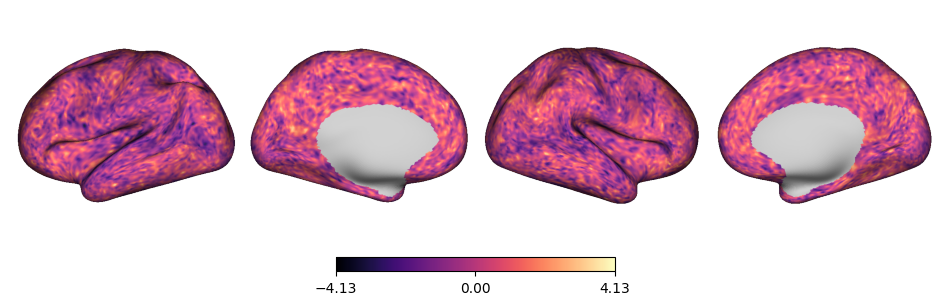

In [13]:
tr = 0
b_values = {"left": voxel_values["left"][tr], "right": voxel_values["right"][tr]}
sfm.surface_plot(b_values, cmap=plt.cm.magma)

# Assessing Dimensionality Reduction Techniques

In [14]:
def pearsonr_hemi(a_values, b_values):
    f_ni = ~ va.utils.get_shared_nan_index(a_values, b_values)
    r_s = scipy.stats.pearsonr(b_values[:, f_ni], a_values[:, f_ni], axis=1)[0]
    return r_s ** 2

Text(0.5, 1.0, 'Parcellation Explained Variance of Voxel BOLD Activity\ntfMRI_MOVIE_7T_DAY_1')

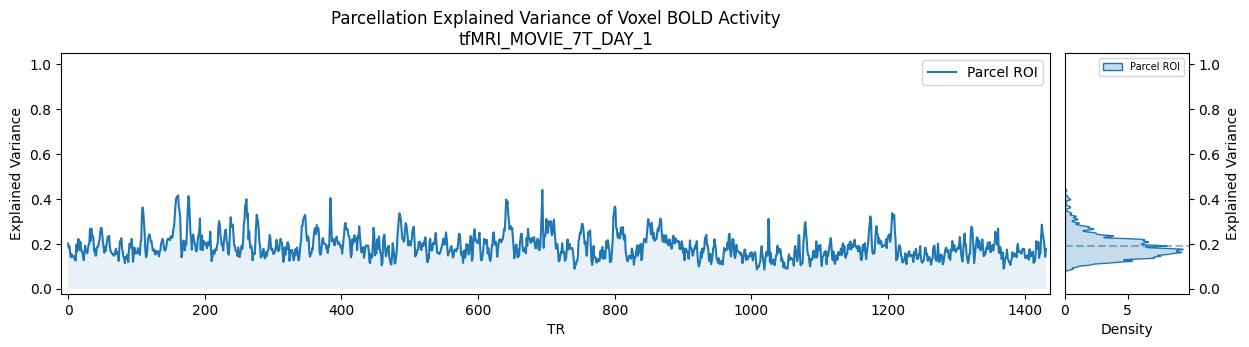

In [15]:
parcel_ev_s = pearsonr_hemi(voxelf_values, parcelf_values)
a0, _ = va.plot.evar_timeseries_plot(parcel_ev_s, label="Parcel ROI")
a0.set_title(f"Parcellation Explained Variance of Voxel BOLD Activity\n{session}")

Text(0.5, 1.0, 'CAP State Explained Variance of Voxel BOLD Activity\ntfMRI_MOVIE_7T_DAY_1')

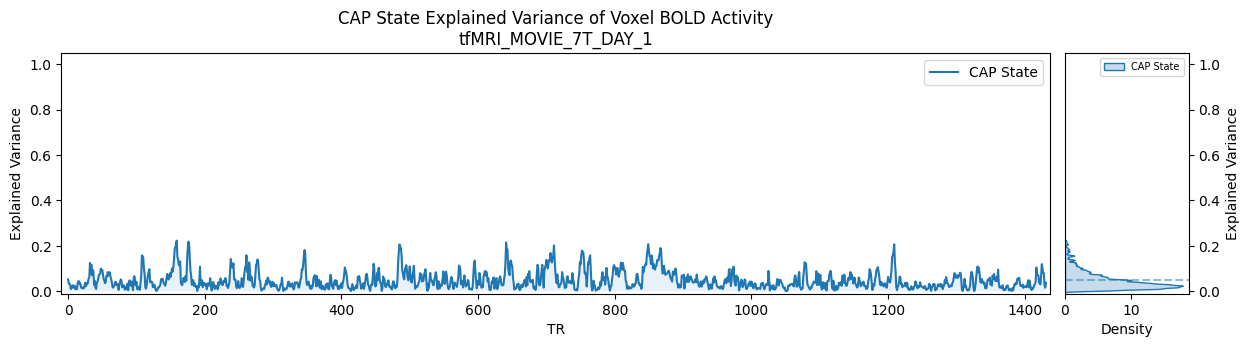

In [16]:
cap_set_values = CAP_tools.utils.cifti_map(ROI_labels, CAP_states, template_cifti)
cap_setf_values = hemisphere_to_full(cap_set_values)
capf_values = cap_setf_values[CAP_labels[subject_index]]

cap_ev_s = pearsonr_hemi(voxelf_values, capf_values)
a0, _ = va.plot.evar_timeseries_plot(cap_ev_s, label="CAP State")
a0.set_title(f"CAP State Explained Variance of Voxel BOLD Activity\n{session}")

Text(0.5, 1.0, 'Explained Variance of Voxel BOLD Activity\ntfMRI_MOVIE_7T_DAY_1')

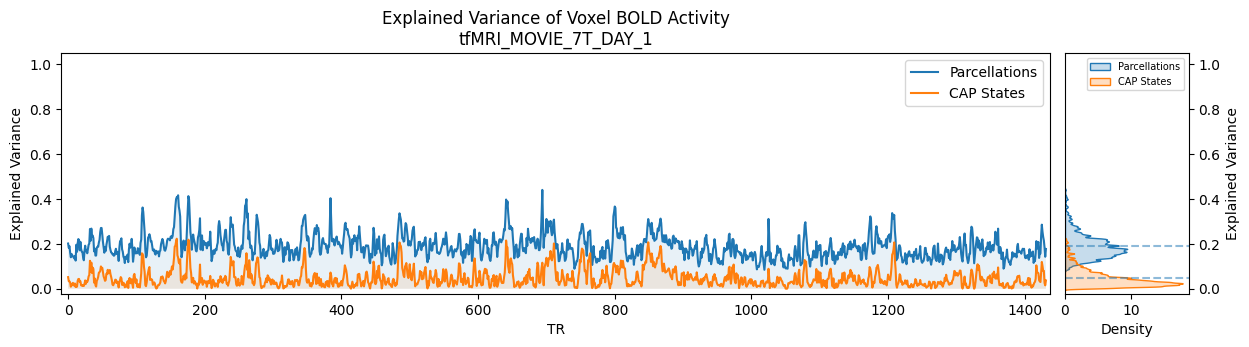

In [17]:
axes = va.plot.evar_timeseries_plot(parcel_ev_s, label="Parcellations")
axes = va.plot.evar_timeseries_plot(cap_ev_s, label="CAP States", axes=axes)
axes[0].set_title(f"Explained Variance of Voxel BOLD Activity\n{session}")

### PCA Explained Variance 

In [18]:
from sklearn.decomposition import PCA

ni = ~np.isnan(voxelf_values).mean(axis=0).astype(bool)
X = voxelf_values[:, ni]

n_pcs = 10

pca = PCA(whiten=False, n_components=n_pcs)
v_pca = pca.fit_transform(X)

In [19]:
PCs = np.full((v_pca.shape[1], *voxelf_values.shape[1:]), fill_value=np.nan)
PCs[:, ni] = pca.components_

recon_X = v_pca @ pca.components_
pcaf_values = np.full(voxelf_values.shape, fill_value=np.nan)
pcaf_values[:, ni] = recon_X
pca_ev_s = pearsonr_hemi(voxelf_values, pcaf_values)

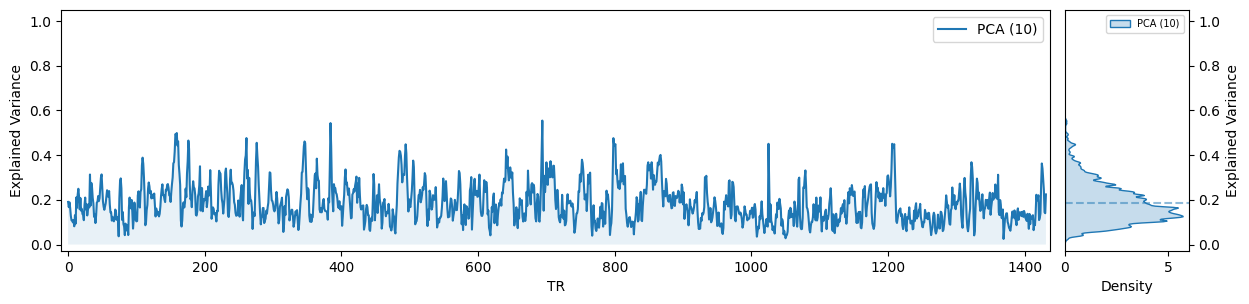

In [20]:
axes = va.plot.evar_timeseries_plot(pca_ev_s, label=f"PCA ({n_pcs})")

Text(0.5, 1.0, 'Example PCA Reconstructed Voxels Frame')

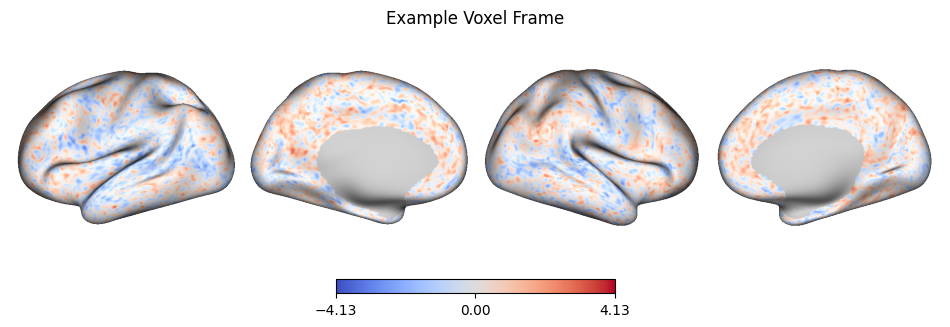

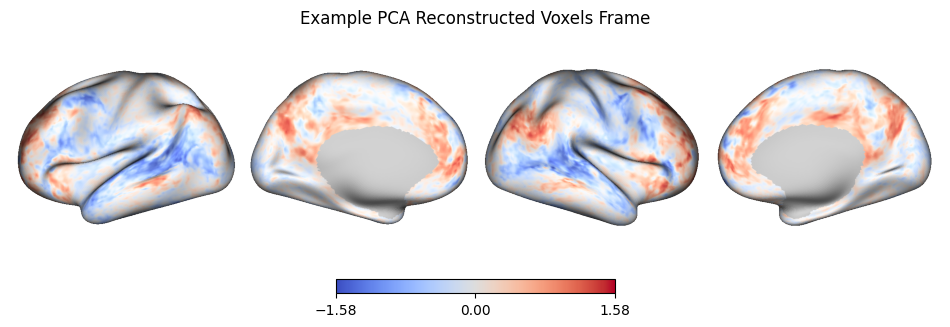

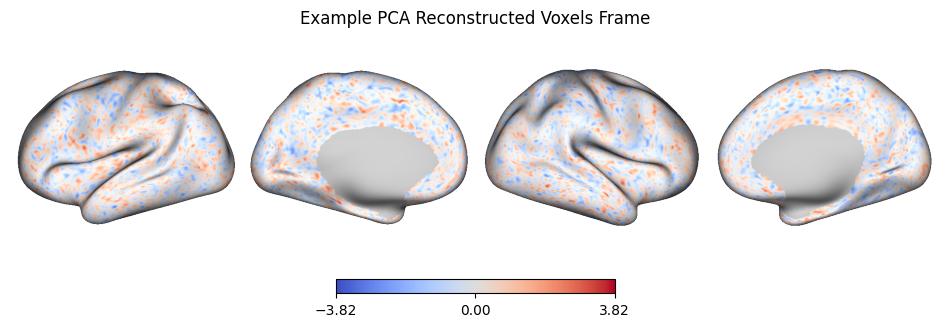

In [21]:
ax, p = sfm.surface_plot(full_to_hemi(voxelf_values[0]), cmap=plt.cm.coolwarm)
ax.set_title("Example Voxel Frame")
pca_values = full_to_hemi(pcaf_values[0])
ax, p = sfm.surface_plot(pca_values, cmap=plt.cm.coolwarm)
ax.set_title("Example PCA Reconstructed Voxels Frame")

delta_values = full_to_hemi(pcaf_values[0] - voxelf_values[0])
ax, p = sfm.surface_plot(delta_values, cmap=plt.cm.coolwarm)
ax.set_title("Example PCA Reconstructed Voxels Frame")

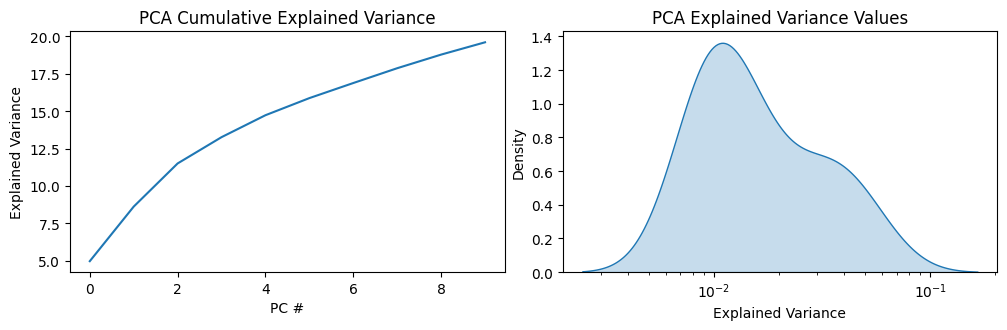

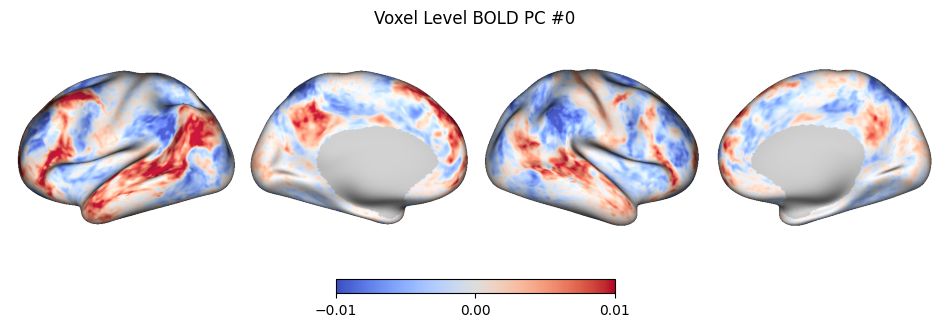

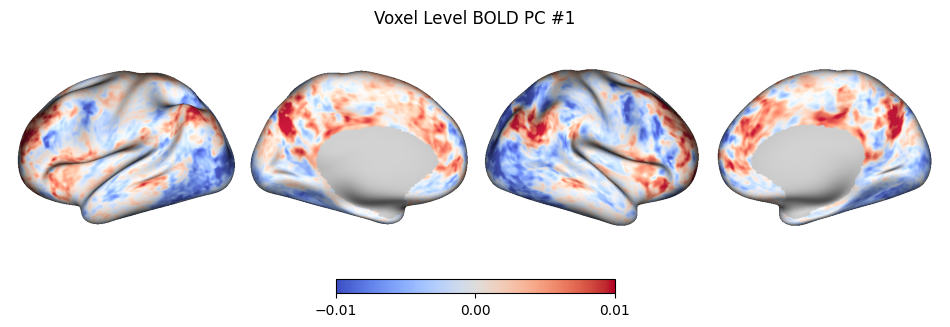

In [22]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3))
fig.tight_layout()
a0.plot(np.cumsum(pca.explained_variance_ratio_) * 100)
# a0.plot(pca.explained_variance_ratio_ * 100, linestyle="--", linewidth=1)
a0.set(xlabel="PC #", title="PCA Cumulative Explained Variance", ylabel="Explained Variance")

sns.kdeplot(pca.explained_variance_ratio_, fill=True, ax=a1, log_scale=True)
a1.set(xlabel="Explained Variance", title="PCA Explained Variance Values");
for pc_index in range(2):
    pc_values = full_to_hemi(PCs[pc_index])
    ax, p = sfm.surface_plot(pc_values, cmap=plt.cm.coolwarm)
    ax.set_title(f"Voxel Level BOLD PC #{pc_index}")

### UMAP Plots of Voxel Data

In [23]:
import umap

In [24]:
reducer = umap.UMAP()
X_tr_umap = reducer.fit_transform(X)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


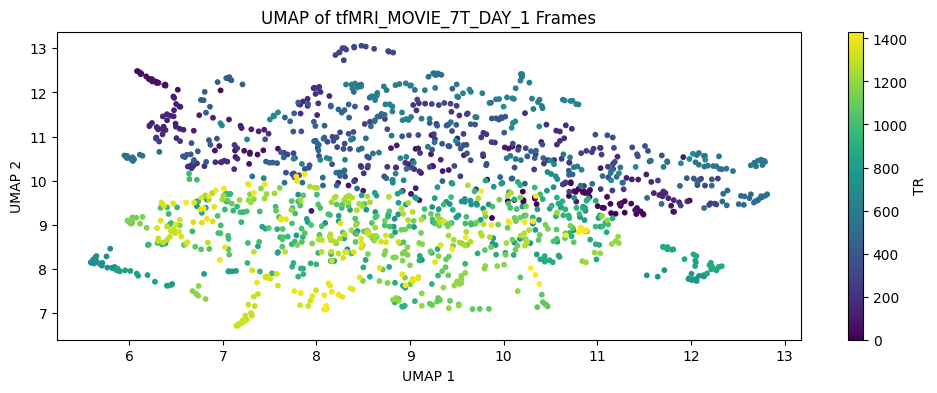

In [25]:
x, y = X_tr_umap.T
fig, ax = plt.subplots(figsize=(12, 4))
sc = ax.scatter(x, y, c=np.arange(len(x)), s=10)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2", title=f"UMAP of {session} Frames");
plt.colorbar(sc, label='TR')

In [26]:
reducer = umap.UMAP()
X_vox_umap = reducer.fit_transform(X.T)

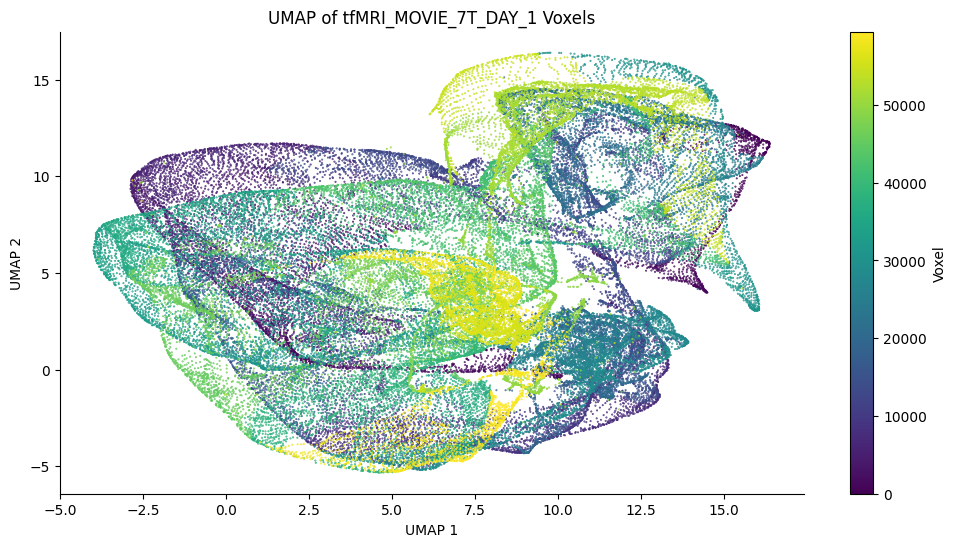

In [27]:
x, y = X_vox_umap.T
fig, ax = plt.subplots(figsize=(12, 6))
sc = ax.scatter(x, y, c=np.arange(len(x)), s=0.2)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2", title=f"UMAP of {session} Voxels");
plt.colorbar(sc, label='Voxel')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

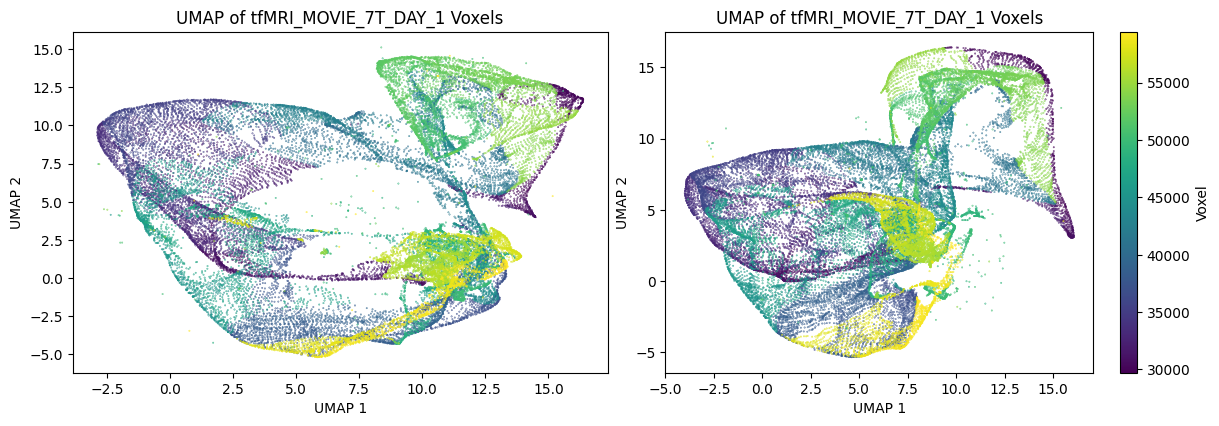

In [28]:
x, y = X_vox_umap.T
ind = np.arange(len(x))
hi = ind > len(x) // 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.tight_layout()
for ax, hi in zip(axes, [ind < len(x) // 2, ind >= len(x) // 2]):
    sc = ax.scatter(x[hi], y[hi], c=ind[hi], s=0.1)
    ax.set(xlabel="UMAP 1", ylabel="UMAP 2", title=f"UMAP of {session} Voxels");
plt.colorbar(sc, label='Voxel')

# Voxel-Voxel associations 

In [37]:
rs_session = "rfMRI_REST1_7T_PA"

rs_dtseries_paths = get_HCP_cifti_paths(rs_session, "dtseries", subject_list)

EC_rs_dtseries_path = "/data/data6/earlycort_7114/ec_00_0013/MNINonLinear/Results/RS_fMRI_maps/RS_fMRI_maps_Atlas_mov_regr_b_lt_resid_brain_regr_resid_DV_FDadapt_frcintrp_bpss_lc2353_hc2_fwhm4.dtseries.nii"
# rs_dtseries_path = rs_dtseries_paths[subject_index]
rs_dtseries_path = EC_rs_dtseries_path
rs_dtseries = nb.load(rs_dtseries_path)
rs_voxels = rs_dtseries.get_fdata()
# np.save('/data/data7/network_control/projects/torch_math_tools/tests/sample_data/dtseries.npy', voxel_data)
# np.save('/data/data7/network_control/projects/torch_math_tools/tests/sample_data/dtseries.npy', rs_voxels)

# Load infomaps Parcellations

In [46]:
index, values = np.load("/data/data7/network_control/projects/torch_math_tools/tests/sample_data/partition.npy")
values = np.random.permutation(np.arange(np.max(values) + 1))[values]
partition = dict(zip(index, values))

736


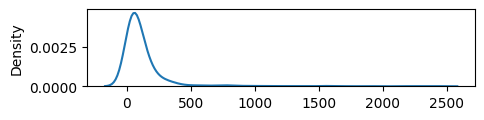

In [51]:
unv, counts = np.unique(values, return_counts=True)
print(len(counts))
fig, ax = plt.subplots(figsize=(5, 1))
sns.kdeplot(counts);

In [65]:
count_filter = np.isin(values, unv[counts >= 0])

In [66]:
voxel_labels = np.full(rs_voxels.shape[1], fill_value=np.nan)
voxel_labels[index[count_filter]] = values[count_filter]

In [67]:
rs_labels = CAP_tools.utils.cifti_map(None, voxel_labels, rs_dtseries)

(<Axes: >, <surfplot.plotting.Plot at 0x554af11d0>)

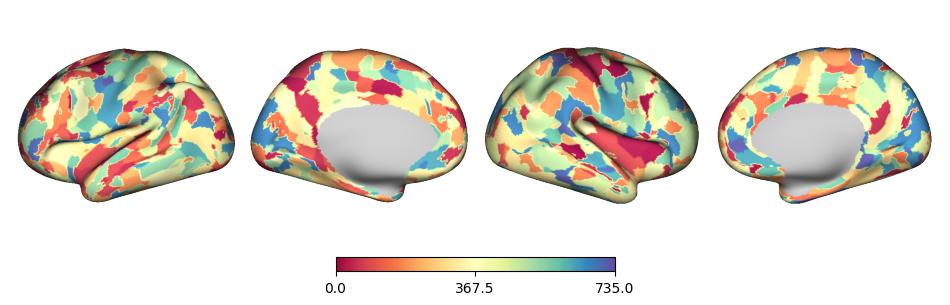

In [68]:
sfm.surface_plot(rs_labels, cmap=plt.cm.Spectral)

# Distance and Subcortical Masking

In [69]:
sfm.get_cortex_mask(rs_dtseries)

array([ True,  True,  True, ..., False, False, False])

In [70]:
dist_dir = "/data/data7/network_control/projects/network_control/resources/brain_distances"
ex_dist_txt_path = os.path.join(dist_dir, "Schaefer400_geodesic_distmat_R.txt")
ex_dist_txt_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

geodesic_distmat_L_path = os.path.join(dist_dir, "dense_geodesic_distmat_L.txt")
geodesic_distmat_R_path = os.path.join(dist_dir, "dense_geodesic_distmat_R.txt")

In [90]:
from scipy.sparse import lil_matrix

def create_sparse_matrix_from_txt(file_path, threshold=10.0, num_voxels=32_492):
    sparse_matrix = lil_matrix((num_voxels, num_voxels), dtype=np.float32)

    pbar = tqdm(total=num_voxels)
    with open(file_path, 'r') as f:
        for i, line in enumerate(f):
            distances = line.strip().split()
            for j, dist in enumerate(distances):
                dist_value = float(dist)
                if dist_value <= threshold and i != j:
                    sparse_matrix[i, j] = dist_value
            pbar.update(1)
    return sparse_matrix

In [91]:
threshold = 30
geodesic_dist_mask_R = create_sparse_matrix_from_txt(geodesic_distmat_R_path, threshold=threshold)
geodesic_dist_mask_L = create_sparse_matrix_from_txt(geodesic_distmat_L_path, threshold=threshold)

  0%|          | 0/32492 [00:00<?, ?it/s]

  0%|          | 0/32492 [00:00<?, ?it/s]

In [92]:
geodesic_mask = scipy.sparse.block_diag([geodesic_dist_mask_L, geodesic_dist_mask_R])
geodesic_mask.resize(91282, 91282)
geodesic_mask = geodesic_mask.tocsr()

geodesic_mask_path = os.path.join(dist_dir, f"geodesic_mask_{threshold}.npz")
scipy.sparse.save_npz(geodesic_mask_path, geodesic_mask)
geodesic_mask

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 111710086 stored elements and shape (91282, 91282)>

# Calculate Euclidian Mask

In [643]:
subcortex_index = ~sfm.get_cortex_mask(rs_dtseries)
subcortex_mask_path = os.path.join(dist_dir, "subcortex_mask.npy")
np.save(subcortex_mask_path, subcortex_index)

In [644]:
subcortex_index = np.load(subcortex_mask_path)
geodesic_mask = scipy.sparse.load_npz(geodesic_mask_path)

In [639]:
sc = tmt.matrix.SparseCorrelator.run(rs_voxels[:, :], sparsity_percent=0.1, mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

SparseCorrelator Block Analysis:   0%|          | 0/8464.0 [00:00<?, ?it/s]

In [645]:
sc = tmt.matrix.Runner.run(rs_voxels[:, :], mask=geodesic_mask,
                                     exclude_index=subcortex_index,
                                     block_size=4000)

<Axes: ylabel='Density'>

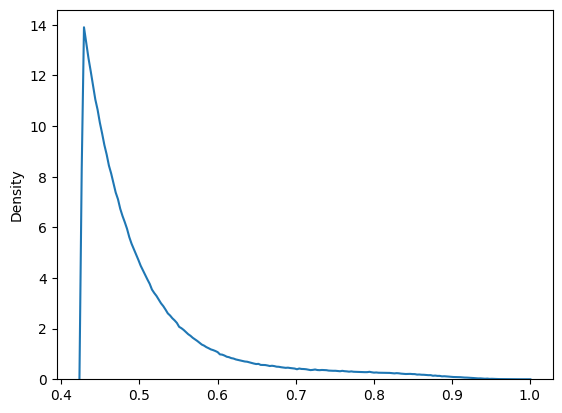

In [37]:
sns.kdeplot(sc.data, bw_method=0.01)

In [38]:
from sklearn.cluster import SpectralClustering
from scipy.sparse import csr_matrix

# Assuming 'sparse_matrix' is your scipy sparse matrix
# model = SpectralClustering(n_clusters=3, affinity='precomputed', n_init=100)
# labels = model.fit_predict(sc)

In [51]:
G = nx.from_scipy_sparse_matrix(sc)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [50]:
import networkx as nx
import community as community_louvain

partition = community_louvain.best_partition(G)

AttributeError: module 'networkx' has no attribute 'from_scipy_sparse_matrix'

In [41]:
(sc.sum(axis=1) == 0).sum()

np.int64(105)

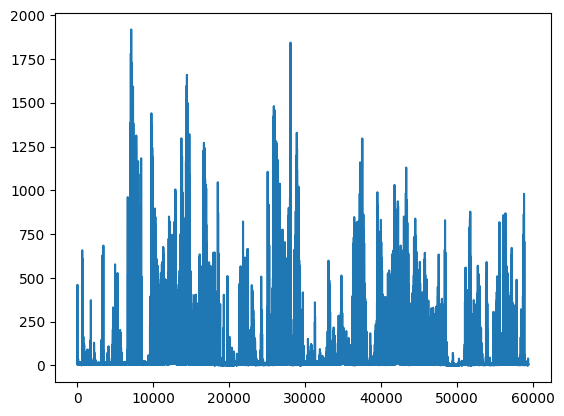

In [49]:
plt.plot(sc.getnnz(axis=0))

# Infomap

# EV Maxs

In [129]:
ev_maxs = tmt.matrix.block_analysis(voxel_data[:, :10000], tmt.matrix.ev_aggregator,
                                    device="mps", use_torch=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [56]:
(ev_maxs >= 0.5).mean() * 100

np.float64(86.18)

<Axes: ylabel='Density'>

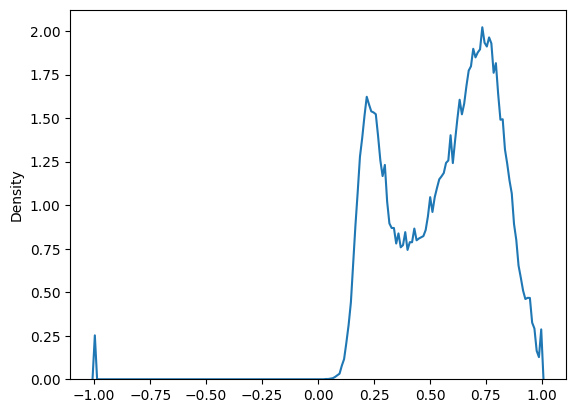

In [179]:
sns.kdeplot(ev_maxs, bw_method=0.01)

[] within parcel vs out of parcel correlations for voxel level

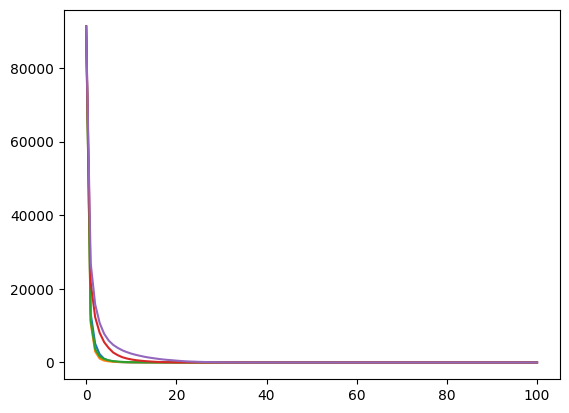

In [558]:
plt.plot(na_counts.T);

In [543]:
na_counts = {thres: [] for thres in np.linspace(0, 1, 101)}